<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# performing the random forest classifier


In [1]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


In [2]:
import pandas as pd
import os

# Assuming the CSV file is named 'heart.csv' within the downloaded path
data_file_path = os.path.join(path, 'heart.csv')
df = pd.read_csv(data_file_path)

print("DataFrame head:")
print(df.head())

DataFrame head:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [3]:
df.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
15,54,F,ATA,120,273,0,Normal,150,N,1.5,Flat,0
608,62,M,ASY,158,170,0,ST,138,Y,0.0,Flat,1
206,35,M,ATA,120,308,0,LVH,180,N,0.0,Up,0
753,34,F,ATA,118,210,0,Normal,192,N,0.7,Up,0
238,48,M,ASY,160,355,0,Normal,99,Y,2.0,Flat,1


In [5]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [12]:
import pandas as pd

# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include='object').columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
print(df_encoded.head())
print("\nDataFrame info after encoding:")
df_encoded.info()

# Re-split the data after encoding
x = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("\nx_train shape after encoding and splitting:", x_train.shape)
print("x_test shape after encoding and splitting:", x_test.shape)

DataFrame after one-hot encoding:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40        140          289          0    172      0.0             0   
1   49        160          180          0    156      1.0             1   
2   37        130          283          0     98      0.0             0   
3   48        138          214          0    108      1.5             1   
4   54        150          195          0    122      0.0             0   

   Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0   True               True              False             False   
1  False              False               True             False   
2   True               True              False             False   
3  False              False              False             False   
4   True              False               True             False   

   RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  \
0               True          Fals

# random forest Classifier with hyper parameters


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [7]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(['HeartDisease'],axis=1),df['HeartDisease'],test_size=0.2,random_state=42)


In [14]:
rc = RandomForestClassifier(n_estimators=100, random_state=42)
rc.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
y_pred = rc.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8750


In [16]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [4, 6, 8, None],
    'criterion': ['gini', 'entropy']
}

# Create a new Random Forest Classifier instance
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(x_train, y_train)

# Print the best parameters and best score
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Evaluate the best estimator on the test set
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(x_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy on the test set with tuned parameters: {accuracy_tuned:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters found: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best cross-validation accuracy: 0.8774
Accuracy on the test set with tuned parameters: 0.8641


# random forest regression with the hyper paramteres with the randomsearch cv


In [17]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define a broader parameter distribution for Randomized Search
param_dist = {
    'n_estimators': randint(100, 500), # Number of trees in the forest
    'max_features': ['sqrt', 'log2', None], # Number of features to consider at every split
    'max_depth': randint(4, 15), # Maximum number of levels in tree
    'min_samples_split': randint(2, 20), # Minimum number of samples required to split a node
    'min_samples_leaf': randint(1, 20), # Minimum number of samples required at each leaf node
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Create a new Random Forest Classifier instance
rf_random = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
# n_iter specifies the number of parameter settings that are sampled
random_search = RandomizedSearchCV(estimator=rf_random, param_distributions=param_dist,
                                   n_iter=100, cv=5, scoring='accuracy', random_state=42,
                                   n_jobs=-1, verbose=1)

# Fit RandomizedSearchCV to the training data
print("\nStarting RandomizedSearchCV...")
random_search.fit(x_train, y_train)

# Print the best parameters and best score
print(f"\nBest parameters found by RandomizedSearchCV: {random_search.best_params_}")
print(f"Best cross-validation accuracy by RandomizedSearchCV: {random_search.best_score_:.4f}")

# Evaluate the best estimator on the test set
best_rf_random = random_search.best_estimator_
y_pred_random_tuned = best_rf_random.predict(x_test)
accuracy_random_tuned = accuracy_score(y_test, y_pred_random_tuned)
print(f"Accuracy on the test set with RandomizedSearchCV tuned parameters: {accuracy_random_tuned:.4f}")


Starting RandomizedSearchCV...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best parameters found by RandomizedSearchCV: {'criterion': 'entropy', 'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 9, 'n_estimators': 273}
Best cross-validation accuracy by RandomizedSearchCV: 0.8746
Accuracy on the test set with RandomizedSearchCV tuned parameters: 0.8641


# feature Importance


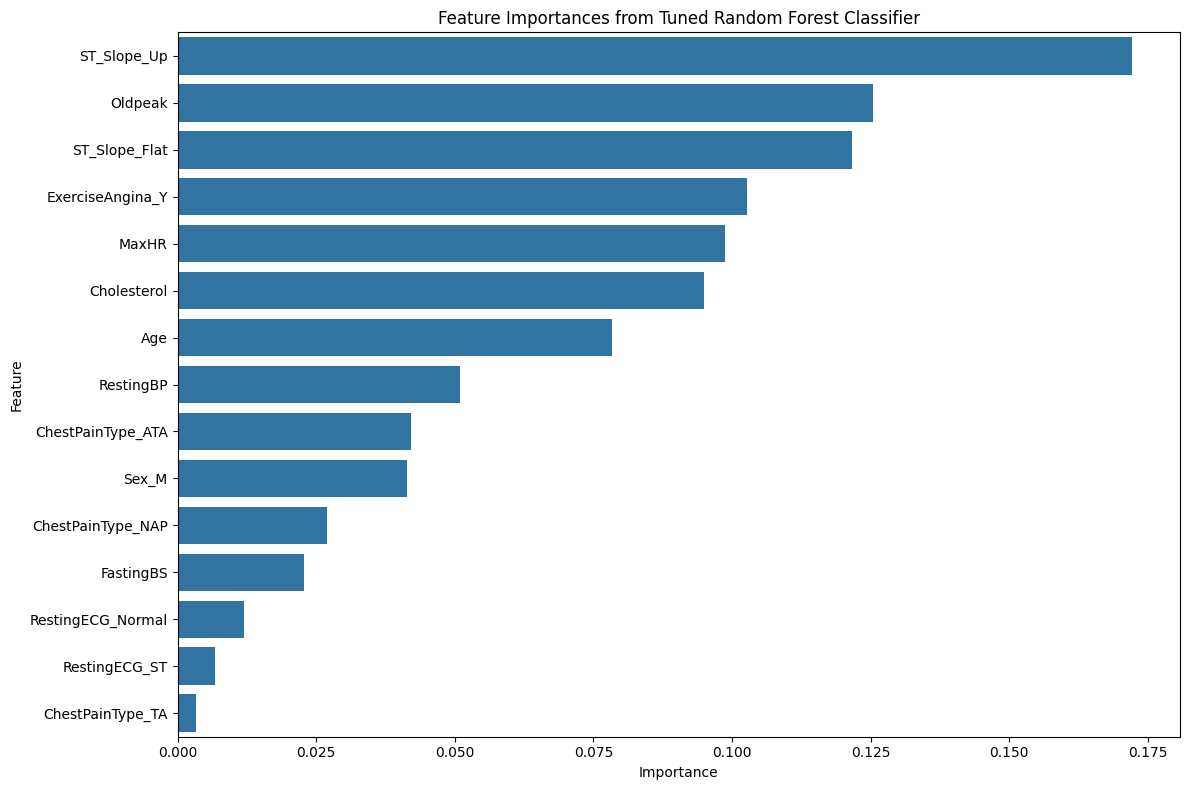

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best model found by RandomizedSearchCV
feature_importances = best_rf_random.feature_importances_

# Get feature names from the training data (x_train)
feature_names = x_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Visualize the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Tuned Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define the parameter grid for Random Forest Regression
param_grid_reg = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [4, 6, 8, None],
    'criterion': ['squared_error', 'absolute_error'] # Corrected criteria for Regressor
}

rf_reg = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
# Scoring for regression: 'neg_mean_squared_error' (to be maximized) or 'r2'
grid_search_reg = GridSearchCV(estimator=rf_reg, param_grid=param_grid_reg, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
print("\nStarting GridSearchCV for Random Forest Regressor...")
grid_search_reg.fit(x_train, y_train)

# Print the best parameters and best score
print(f"\nBest parameters found by GridSearchCV for Regressor: {grid_search_reg.best_params_}")
# The best_score_ will be negative for 'neg_mean_squared_error', so convert it to MSE
best_mse_cv = -grid_search_reg.best_score_
print(f"Best cross-validation RMSE: {np.sqrt(best_mse_cv):.4f}") # Report RMSE for interpretability

# Evaluate the best estimator on the test set
best_rf_reg = grid_search_reg.best_estimator_
y_pred_grid_reg = best_rf_reg.predict(x_test)

# Calculate regression metrics
mse_test = mean_squared_error(y_test, y_pred_grid_reg)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_grid_reg)

print(f"Test Set RMSE with GridSearchCV tuned Regressor parameters: {rmse_test:.4f}")
print(f"Test Set R-squared with GridSearchCV tuned Regressor parameters: {r2_test:.4f}")


Starting GridSearchCV for Random Forest Regressor...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters found by GridSearchCV for Regressor: {'criterion': 'squared_error', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 300}
Best cross-validation RMSE: 0.3232
Test Set RMSE with GridSearchCV tuned Regressor parameters: 0.3201
Test Set R-squared with GridSearchCV tuned Regressor parameters: 0.5790


# random forest regressor


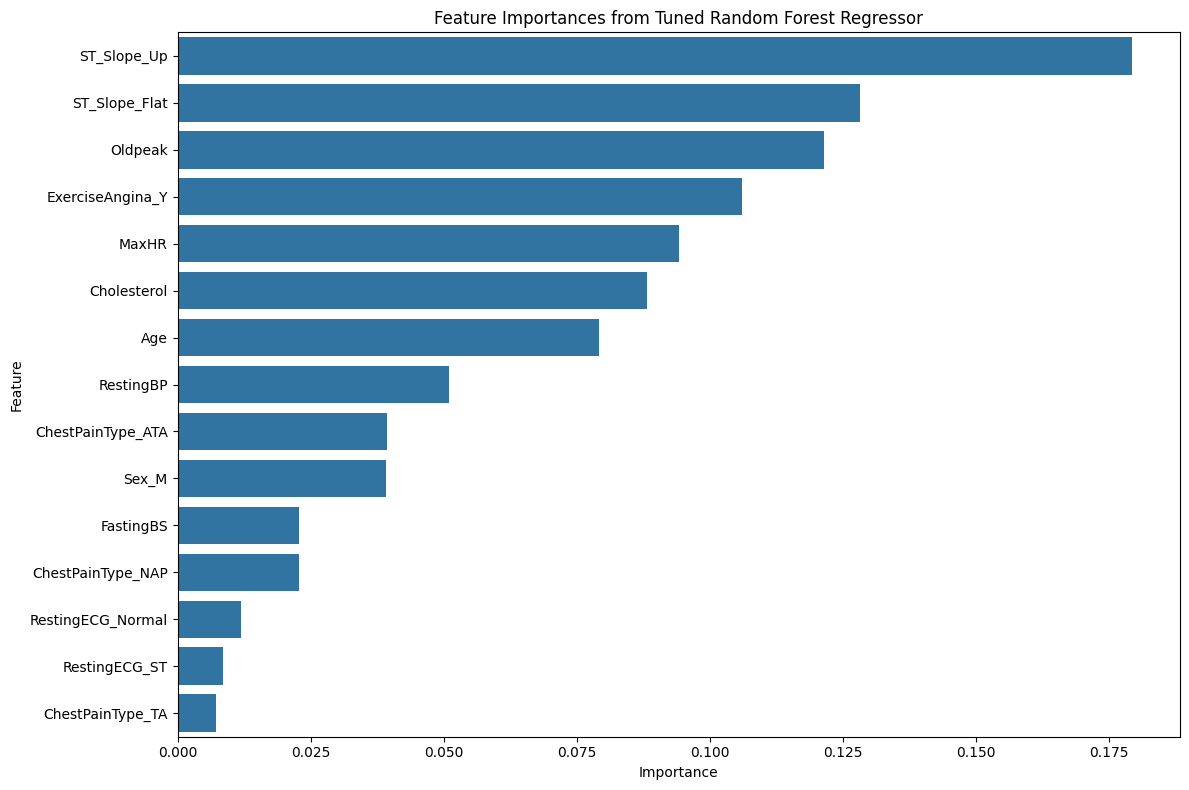

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the best model found by GridSearchCV for Regressor
feature_importances_reg = best_rf_reg.feature_importances_

# Get feature names from the training data (x_train)
feature_names_reg = x_train.columns

# Create a DataFrame for better visualization
importance_df_reg = pd.DataFrame({
    'Feature': feature_names_reg,
    'Importance': feature_importances_reg
})

# Sort the features by importance in descending order
importance_df_reg = importance_df_reg.sort_values(by='Importance', ascending=False)

# Visualize the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_reg)
plt.title('Feature Importances from Tuned Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# apply the random forest on the iris data set

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'iris' dataset.
Path to dataset files: /kaggle/input/iris


In [3]:
import pandas as pd
import os

# Assuming the CSV file is named 'Iris.csv' within the downloaded path
iris_file_path = os.path.join(path, 'Iris.csv')
iris_df = pd.read_csv(iris_file_path)

print("Iris DataFrame head:")
print(iris_df.head())

Iris DataFrame head:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [6]:
import pandas as pd

# Combine features and the encoded target into a single DataFrame
enterprise_iris_df = X_iris.copy()
enterprise_iris_df['Species_Encoded'] = y_iris_encoded

print("Enterprise Iris DataFrame head:")
print(enterprise_iris_df.head())
print("\nEnterprise Iris DataFrame info:")
enterprise_iris_df.info()

Enterprise Iris DataFrame head:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species_Encoded
0            5.1           3.5            1.4           0.2                0
1            4.9           3.0            1.4           0.2                0
2            4.7           3.2            1.3           0.2                0
3            4.6           3.1            1.5           0.2                0
4            5.0           3.6            1.4           0.2                0

Enterprise Iris DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SepalLengthCm    150 non-null    float64
 1   SepalWidthCm     150 non-null    float64
 2   PetalLengthCm    150 non-null    float64
 3   PetalWidthCm     150 non-null    float64
 4   Species_Encoded  150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 

### Hyperparameter Tuning for Iris Random Forest Classifier using GridSearchCV

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Drop the 'Id' column as it's not a feature
iris_df_processed = iris_df.drop('Id', axis=1)

# Separate features (X) and target (y)
X_iris = iris_df_processed.drop('Species', axis=1)
y_iris = iris_df_processed['Species']

# Encode the target variable if it's categorical (which 'Species' is)
le = LabelEncoder()
y_iris_encoded = le.fit_transform(y_iris)

# Split the data into training and testing sets
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(X_iris, y_iris_encoded, test_size=0.3, random_state=42)

print("Features (X_iris) head:")
print(X_iris.head())
print("\nTarget (y_iris_encoded) head:")
print(y_iris_encoded[:5])
print("\nX_iris_train shape:", X_iris_train.shape)
print("X_iris_test shape:", X_iris_test.shape)
print("y_iris_train shape:", y_iris_train.shape)
print("y_iris_test shape:", y_iris_test.shape)

Features (X_iris) head:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target (y_iris_encoded) head:
[0 0 0 0 0]

X_iris_train shape: (105, 4)
X_iris_test shape: (45, 4)
y_iris_train shape: (105,)
y_iris_test shape: (45,)


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize a Random Forest Classifier
iris_rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier
iris_rf_clf.fit(X_iris_train, y_iris_train)

# Make predictions on the test set
y_iris_pred = iris_rf_clf.predict(X_iris_test)

# Evaluate the model
iris_accuracy = accuracy_score(y_iris_test, y_iris_pred)
print(f"Random Forest Classifier Accuracy on Iris dataset: {iris_accuracy:.4f}")

Random Forest Classifier Accuracy on Iris dataset: 1.0000


In [11]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest Classifier on Iris dataset
param_grid_iris = {
    'n_estimators': [50, 100, 150, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [4, 6, 8, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'n_jobs': [-1]  # Use all available CPU cores
}

# Create a new Random Forest Classifier instance (using the same random_state for reproducibility)
rf_iris = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_iris = GridSearchCV(estimator=rf_iris, param_grid=param_grid_iris, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the Iris training data
print("\nStarting GridSearchCV for Iris Random Forest Classifier...")
grid_search_iris.fit(X_iris_train, y_iris_train)

# Print the best parameters and best score
print(f"\nBest parameters found by GridSearchCV for Iris: {grid_search_iris.best_params_}")
print(f"Best cross-validation accuracy by GridSearchCV for Iris: {grid_search_iris.best_score_:.4f}")

# Evaluate the best estimator on the Iris test set
best_rf_iris = grid_search_iris.best_estimator_
y_iris_pred_tuned = best_rf_iris.predict(X_iris_test)
accuracy_iris_tuned = accuracy_score(y_iris_test, y_iris_pred_tuned)
print(f"Accuracy on the Iris test set with tuned parameters: {accuracy_iris_tuned:.4f}")


Starting GridSearchCV for Iris Random Forest Classifier...
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits

Best parameters found by GridSearchCV for Iris: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100, 'n_jobs': -1}
Best cross-validation accuracy by GridSearchCV for Iris: 0.9429
Accuracy on the Iris test set with tuned parameters: 1.0000


<Figure size 800x600 with 0 Axes>

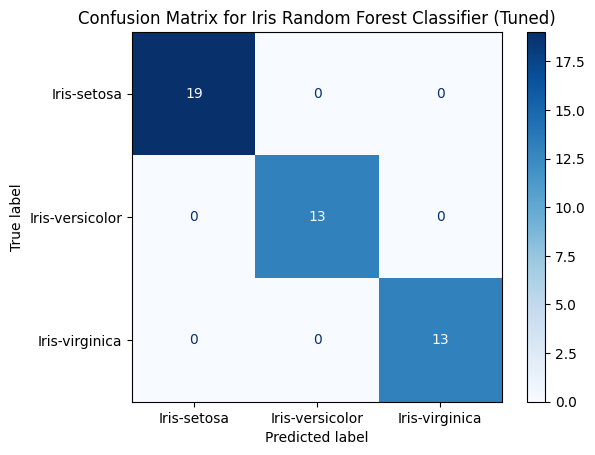

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix using the predictions from the best tuned model
cm_iris = confusion_matrix(y_iris_test, y_iris_pred_tuned)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
display = ConfusionMatrixDisplay(confusion_matrix=cm_iris, display_labels=le.classes_)
display.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Iris Random Forest Classifier (Tuned)')
plt.show()